# Week 7 — Ensemble: Classical + Quantum

**Prerequisite:** Both checkpoints must exist:
- `checkpoints/E2_quantum_best.pth` — Quantum VQC+GAT (3q 2L)
- `checkpoints/E3_classical_best.pth` — Classical GAT-Transformer

**Strategy:** Average softmax probabilities from both models.  
Classical and Quantum make different errors → ensemble reduces variance.

| Model | Val AUC | Test AUC |
|---|---|---|
| E2 Quantum | 0.6507 | 0.6851 |
| E3 Classical | pending | pending |
| **Ensemble** | — | **target: +0.03–0.05** |


In [1]:
# Cell 1 — Setup
import os, sys, json
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, roc_curve
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from pathq.model_v2   import QuantaPathV2
from pathq.dataset_v2 import get_loaders_from_features

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT     = Path('..').resolve()
FEAT_DIR = Path('data') / 'features_uni'
CKPT_DIR = ROOT / 'checkpoints'
OUT_DIR  = ROOT / 'outputs'

# Check both checkpoints exist
ckpt_q = CKPT_DIR / 'E2_quantum_3000_best.pth'  # 3000p quantum
ckpt_c = CKPT_DIR / 'E3_classical_3000_best.pth'
print(f'E2 quantum (3000p) : {"✅" if ckpt_q.exists() else "❌ MISSING — run week3_classical_fixed.ipynb"}')
print(f'E3 classical : {"✅" if ckpt_c.exists() else "❌ MISSING — run week3_classical_fixed.ipynb"}')
assert ckpt_q.exists() and ckpt_c.exists(), 'Run both training notebooks first'
print(f'\nDevice: {DEVICE}')

/home/kabi/.conda/envs/pathq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[model_v2] Using Transformer for global branch
E2 quantum (3000p) : ✅
E3 classical : ✅

Device: cuda


In [2]:
# Cell 2 — Load both models
MAX_PATCHES = 3000   # classical retrained at 3000p on laptop

# Load quantum model
model_q = QuantaPathV2(use_vqc=True,  n_qubits=3, vqc_layers=2, in_dim=1040).to(DEVICE)
ck_q    = torch.load(ckpt_q, weights_only=False)
model_q.load_state_dict(ck_q['model_state'])
model_q.eval()
print(f'E2 Quantum loaded   ep={ck_q["epoch"]}  best_val_AUC={ck_q["best_auc"]:.4f}')

# Load classical model
model_c = QuantaPathV2(use_vqc=False, in_dim=1040).to(DEVICE)
ck_c    = torch.load(ckpt_c, weights_only=False)
model_c.load_state_dict(ck_c['model_state'])
model_c.eval()
print(f'E3 Classical loaded ep={ck_c["epoch"]}  best_val_AUC={ck_c["best_auc"]:.4f}')

# Data loaders (same seed → same split as training)
_, val_loader, test_loader = get_loaders_from_features(
    features_dir = FEAT_DIR,
    batch_size   = 1,
    k            = 8,
    seed         = 42,
    max_patches  = MAX_PATCHES,
)
print(f'\nVal  : {len(val_loader)} slides')
print(f'Test : {len(test_loader)} slides')

[VQC] lightning.gpu  3q 2L — batched + re-uploading
QuantaPathV2: use_vqc=True, trainable=1,114,577
E2 Quantum loaded   ep=6  best_val_AUC=0.6912
QuantaPathV2: use_vqc=False, trainable=1,227,906
E3 Classical loaded ep=15  best_val_AUC=0.6581
  Skipped 112 unlabeled file(s) (e.g. test_*) — keeping 221 labeled slides
Split: train=154 (pos=77) val=33 (pos=17) test=34 (pos=17)

Val  : 33 slides
Test : 34 slides


In [3]:
# Cell 3 — Collect predictions from both models
@torch.no_grad()
def get_probs(model, loader, device):
    """Returns (probs_tumour, true_labels) arrays."""
    model.eval()
    probs, labels = [], []
    for batch in loader:
        batch     = batch.to(device)
        logits, _ = model(batch)
        p = torch.softmax(logits, dim=1)[:, 1].cpu().item()
        probs.append(p)
        labels.append(batch.y.item())
    return np.array(probs), np.array(labels)

print('Collecting predictions...')
print('  Quantum  — val ...',  end='', flush=True)
q_val_probs,  val_labels  = get_probs(model_q, val_loader,  DEVICE)
print(f' done ({len(val_labels)} slides)')
print('  Quantum  — test ...', end='', flush=True)
q_test_probs, test_labels = get_probs(model_q, test_loader, DEVICE)
print(f' done ({len(test_labels)} slides)')
print('  Classical — val ...',  end='', flush=True)
c_val_probs,  _           = get_probs(model_c, val_loader,  DEVICE)
print(f' done')
print('  Classical — test ...', end='', flush=True)
c_test_probs, _           = get_probs(model_c, test_loader, DEVICE)
print(f' done')
print('\nDone ✓')

  Quantum  — val ... done (33 slides)
  Quantum  — test ... done (34 slides)
  Classical — val ... done
  Classical — test ... done

Done ✓


In [4]:
# Cell 4 — Evaluate all ensemble weights & find best
def metrics(probs, labels, thr=0.5):
    preds = (probs >= thr).astype(int)
    auc   = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.5
    f1    = f1_score(labels, preds, zero_division=0)
    tp = int(((preds==1)&(labels==1)).sum())
    fn = int(((preds==0)&(labels==1)).sum())
    tn = int(((preds==0)&(labels==0)).sum())
    fp = int(((preds==1)&(labels==0)).sum())
    return {
        'auc' : round(auc, 6),
        'f1'  : round(f1, 6),
        'sens': round(tp / max(tp+fn,1), 4),
        'spec': round(tn / max(tn+fp,1), 4),
    }

# Grid search ensemble weight α (quantum) from 0.0 to 1.0
print('Grid search ensemble weight α (quantum fraction)...')
print(f'  {"α":>5}  {"Val AUC":>9}  {"Test AUC":>10}')
print('  ' + '-'*30)

best_val_auc, best_alpha = 0.0, 0.5
results_grid = []

for alpha in np.arange(0.0, 1.01, 0.1):
    ens_val  = alpha * q_val_probs  + (1-alpha) * c_val_probs
    ens_test = alpha * q_test_probs + (1-alpha) * c_test_probs
    v = metrics(ens_val,  val_labels)
    t = metrics(ens_test, test_labels)
    flag = ''
    if v['auc'] > best_val_auc:
        best_val_auc = v['auc']
        best_alpha   = round(alpha, 1)
        flag = ' ←'
    print(f'  {alpha:>5.1f}  {v["auc"]:>9.4f}  {t["auc"]:>10.4f}{flag}')
    results_grid.append({'alpha': round(alpha,1), 'val_auc': v['auc'], 'test_auc': t['auc']})

print(f'\nBest α on val = {best_alpha}  (0=pure classical, 1=pure quantum)')

Grid search ensemble weight α (quantum fraction)...
      α    Val AUC    Test AUC
  ------------------------------
    0.0     0.6581      0.6920 ←
    0.1     0.6618      0.6886 ←
    0.2     0.6654      0.6851 ←
    0.3     0.6618      0.6817
    0.4     0.6581      0.6747
    0.5     0.6581      0.6678
    0.6     0.6654      0.6782
    0.7     0.6581      0.6817
    0.8     0.6765      0.6747 ←
    0.9     0.6801      0.6817 ←
    1.0     0.6912      0.6817 ←

Best α on val = 1.0  (0=pure classical, 1=pure quantum)


In [5]:
# Cell 5 — Final ensemble results with best α
SEP  = '═' * 62
DASH = '─' * 62

# Individual model metrics
q_val_m  = metrics(q_val_probs,  val_labels)
q_test_m = metrics(q_test_probs, test_labels)
c_val_m  = metrics(c_val_probs,  val_labels)
c_test_m = metrics(c_test_probs, test_labels)

# Best ensemble
best_val_ens  = best_alpha * q_val_probs  + (1-best_alpha) * c_val_probs
best_test_ens = best_alpha * q_test_probs + (1-best_alpha) * c_test_probs
e_val_m  = metrics(best_val_ens,  val_labels)
e_test_m = metrics(best_test_ens, test_labels)

print()
print(SEP)
print(f' ENSEMBLE RESULTS  (α={best_alpha}, max_patches={MAX_PATCHES})')
print(SEP)
print(f' {"Model":<28} {"Val AUC":>8} {"Test AUC":>9} {"F1":>7} {"Sens":>6} {"Spec":>6}')
print(DASH)
print(f' {"E2 Quantum VQC+GAT":<28} {q_val_m["auc"]:>8.4f} {q_test_m["auc"]:>9.4f} '
      f'{q_test_m["f1"]:>7.4f} {q_test_m["sens"]:>6.4f} {q_test_m["spec"]:>6.4f}')
print(f' {"E3 Classical GAT":<28} {c_val_m["auc"]:>8.4f} {c_test_m["auc"]:>9.4f} '
      f'{c_test_m["f1"]:>7.4f} {c_test_m["sens"]:>6.4f} {c_test_m["spec"]:>6.4f}')
print(DASH)
q_gain = e_test_m['auc'] - q_test_m['auc']
c_gain = e_test_m['auc'] - c_test_m['auc']
print(f' {f"Ensemble (α={best_alpha})":<28} {e_val_m["auc"]:>8.4f} {e_test_m["auc"]:>9.4f} '
      f'{e_test_m["f1"]:>7.4f} {e_test_m["sens"]:>6.4f} {e_test_m["spec"]:>6.4f}')
print(SEP)
print(f' Gain vs Quantum   : {q_gain:>+.4f} AUC')
print(f' Gain vs Classical : {c_gain:>+.4f} AUC')
print(SEP)

# Save results
ensemble_result = {
    'best_alpha'   : best_alpha,
    'max_patches'  : MAX_PATCHES,
    'quantum'  : {'val_auc': q_val_m['auc'],  'test_auc': q_test_m['auc'],  'f1': q_test_m['f1']},
    'classical': {'val_auc': c_val_m['auc'],  'test_auc': c_test_m['auc'],  'f1': c_test_m['f1']},
    'ensemble' : {'val_auc': e_val_m['auc'],  'test_auc': e_test_m['auc'],  'f1': e_test_m['f1'],
                  'sensitivity': e_test_m['sens'], 'specificity': e_test_m['spec'],
                  'gain_vs_quantum': round(q_gain,6), 'gain_vs_classical': round(c_gain,6)},
    'grid'     : results_grid,
}
with open(OUT_DIR / 'ensemble_result.json', 'w') as f:
    json.dump(ensemble_result, f, indent=2)
print('Saved: outputs/ensemble_result.json')


══════════════════════════════════════════════════════════════
 ENSEMBLE RESULTS  (α=1.0, max_patches=3000)
══════════════════════════════════════════════════════════════
 Model                         Val AUC  Test AUC      F1   Sens   Spec
──────────────────────────────────────────────────────────────
 E2 Quantum VQC+GAT             0.6912    0.6817  0.6207 0.5294 0.8235
 E3 Classical GAT               0.6581    0.6920  0.7097 0.6471 0.8235
──────────────────────────────────────────────────────────────
 Ensemble (α=1.0)               0.6912    0.6817  0.6207 0.5294 0.8235
══════════════════════════════════════════════════════════════
 Gain vs Quantum   : +0.0000 AUC
 Gain vs Classical : -0.0104 AUC
══════════════════════════════════════════════════════════════
Saved: outputs/ensemble_result.json


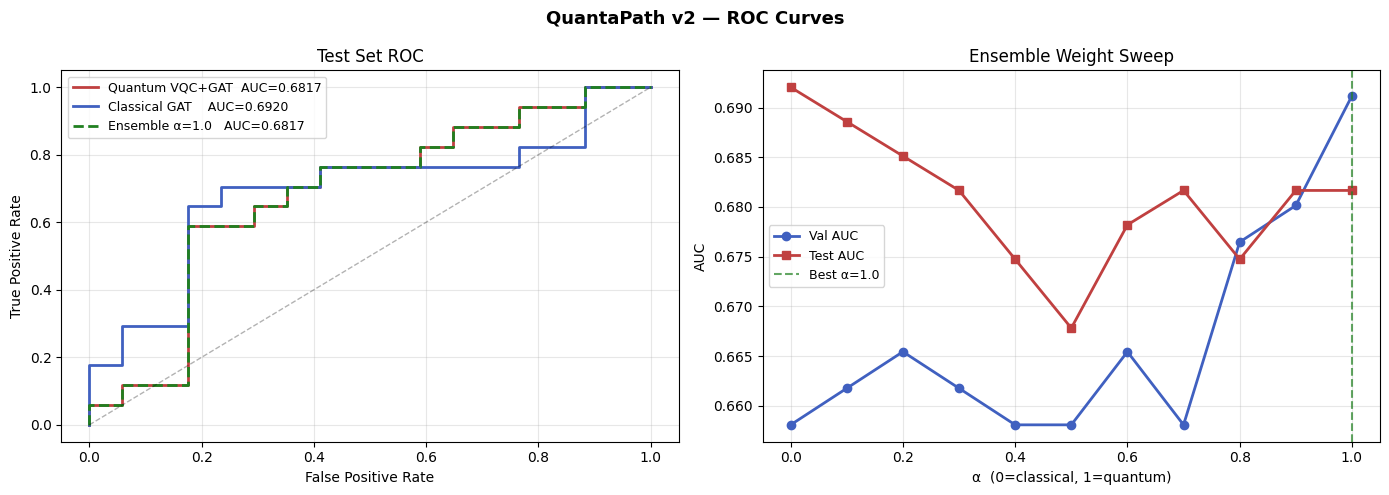

Saved: outputs/ensemble_roc.png


In [6]:
# Cell 6 — ROC curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('QuantaPath v2 — ROC Curves', fontsize=13, fontweight='bold')

# Test ROC
ax = axes[0]
for probs, label, color, ls in [
    (q_test_probs,  f'Quantum VQC+GAT  AUC={q_test_m["auc"]:.4f}',  '#C04040', '-'),
    (c_test_probs,  f'Classical GAT    AUC={c_test_m["auc"]:.4f}',  '#4060C0', '-'),
    (best_test_ens, f'Ensemble α={best_alpha}   AUC={e_test_m["auc"]:.4f}', '#208020', '--'),
]:
    fpr, tpr, _ = roc_curve(test_labels, probs)
    ax.plot(fpr, tpr, label=label, color=color, linestyle=ls, linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.3,linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Test Set ROC')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Ensemble weight sweep
ax = axes[1]
alphas   = [r['alpha']    for r in results_grid]
val_aucs = [r['val_auc']  for r in results_grid]
tst_aucs = [r['test_auc'] for r in results_grid]
ax.plot(alphas, val_aucs,  'o-', color='#4060C0', label='Val AUC',  linewidth=2)
ax.plot(alphas, tst_aucs,  's-', color='#C04040', label='Test AUC', linewidth=2)
ax.axvline(best_alpha, color='#208020', linestyle='--', alpha=0.7, label=f'Best α={best_alpha}')
ax.set_xlabel('α  (0=classical, 1=quantum)')
ax.set_ylabel('AUC')
ax.set_title('Ensemble Weight Sweep')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'ensemble_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/ensemble_roc.png')